In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Go up two levels: notebooks/training -> notebooks -> project_root
project_root = Path('../..').resolve()
print('Project root:', project_root)

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from uais.anomaly.train_isolation_forest import train_isolation_forest, compute_anomaly_score
from uais.utils.metrics import compute_classification_metrics
from uais.utils.plotting import plot_roc_curve, plot_pr_curve

Project root: /Users/pratik_n/Desktop/MyComputer/universal-anomaly-intelligence-v2


In [2]:
# Helper: clean DataFrame to avoid missing-column/NaN errors
import pandas as pd

def clean_frame(df, target=None, numeric_expected=None, categorical_expected=None):
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    df = df.dropna(axis=1, how='all').copy()
    numeric_expected = numeric_expected or []
    categorical_expected = categorical_expected or []
    for col in numeric_expected:
        if col not in df.columns:
            df[col] = 0.0
    for col in categorical_expected:
        if col not in df.columns:
            df[col] = 'missing'
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(exclude=['number']).columns
    if len(num_cols):
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    if len(cat_cols):
        df[cat_cols] = df[cat_cols].fillna('missing')
    if target:
        if target not in df.columns:
            raise KeyError(f"Target '{target}' missing. Columns: {df.columns.tolist()}")
        df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
    return df


In [3]:
feats_path = project_root / 'data' / 'processed' / 'fraud' / 'fraud_features.parquet'
df_feats = pd.read_parquet(feats_path)
df_feats = clean_frame(df_feats, target='Class')
print('After cleaning features:', df_feats.shape)

target_col = 'Class'
X = df_feats.drop(columns=[target_col])
y = df_feats[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape, 'Test:', X_test.shape)


After cleaning features: (283726, 35)
Train: (226980, 34) Test: (56746, 34)


In [4]:
iso_model, scaler = train_isolation_forest(
    X_train,
    random_state=42,
    contamination=0.01,
)

anomaly_scores_test = compute_anomaly_score(iso_model, scaler, X_test)
print('Anomaly scores (test) min/max:', anomaly_scores_test.min(), anomaly_scores_test.max())


Anomaly scores (test) min/max: 0.0 1.0


Metrics using anomaly scores alone:
roc_auc: 0.9318
pr_auc: 0.0830
f1: 0.1183
precision: 0.0660
recall: 0.5684
accuracy: 0.9858


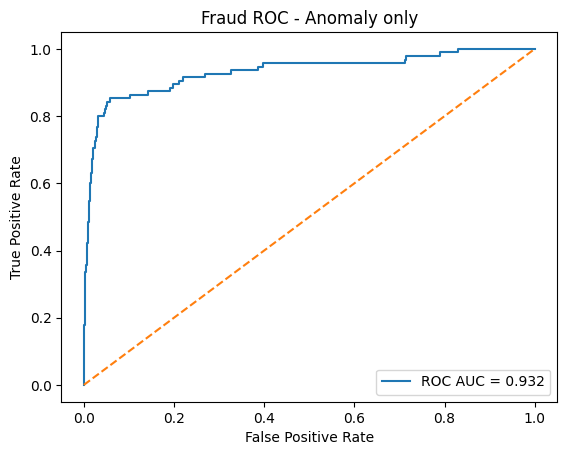

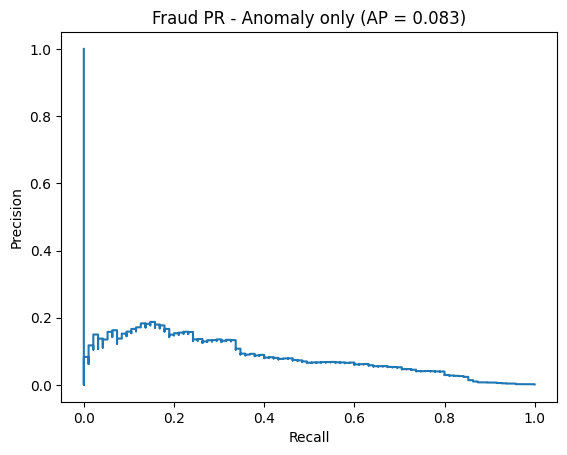

In [5]:
anomaly_metrics = compute_classification_metrics(y_test.values, anomaly_scores_test, threshold=0.5)

print('Metrics using anomaly scores alone:')
for k, v in anomaly_metrics.items():
    print(f"{k}: {v:.4f}")

plot_roc_curve(y_test.values, anomaly_scores_test, title='Fraud ROC - Anomaly only')
plot_pr_curve(y_test.values, anomaly_scores_test, title='Fraud PR - Anomaly only')
